# Many-Facet Partial Credit Model (MF-PCM) — Bayesian Estimation with Stan

## 1. Model Description

The **Many-Facet PCM** combines the **Partial Credit Model** (Masters, 1982) for polytomous responses with a **rater/judge facet** (Linacre, 1989). It is appropriate for performance assessments where raters assign partial scores (0, 1, …, K–1).

### Adjacent-Category Log-Odds

$$\log \frac{P(X_{jir} = k)}{P(X_{jir} = k-1)} = \theta_j - \delta_{ik} - \phi_r, \quad k = 1, \ldots, K-1$$

### Category Probabilities

$$P(X_{jir} = k) \propto \exp\!\left(k\theta_j - \sum_{m=1}^{k}(\delta_{im} + \phi_r)\right)$$

Equivalently, using cumulative log-scores:
$$\ell_0 = 0, \quad \ell_k = \ell_{k-1} + (\theta_j - \delta_{ik} - \phi_r), \quad k \geq 1$$
$$P(X = k) = \frac{\exp(\ell_k)}{\sum_m \exp(\ell_m)}$$

| Parameter | Interpretation |
|-----------|----------------|
| $\theta_j$ | Person ability |
| $\delta_{ik}$ | Step-$k$ difficulty in item $i$ |
| $\phi_r$ | Rater severity (positive = harsher) |

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad \delta_{ik} \sim \mathcal{N}(0,2), \quad \phi_r \sim \mathcal{N}(0,1) \text{ with sum-to-zero}$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

- 77 persons × 4 items × 5 raters, **4 ordered score categories** (0–3).
- 학생 수 증가에 따른 파라메터의 정확도(불확실성 - posterior width)를 관찰하시오.

In [2]:
J, I, R, K = 77, 20, 5, 4

theta_true = np.random.normal(0, 1, J)
delta_true = np.random.normal(0, 1.0, (I, K - 1))  # step difficulties free order
delta_true[0] = [-1.2, 0.0, 1.5]  # item 1 with clear steps

phi_raw    = np.random.normal(0, 0.6, R)
phi_true   = phi_raw - phi_raw.mean()

def pcm_probs(theta, delta, phi=0.0):
    """PCM (with optional rater offset phi)."""
    log_p = np.zeros(K)
    for k in range(1, K):
        log_p[k] = log_p[k-1] + (theta - delta[k-1] - phi)
    log_p -= log_p.max()
    probs = np.exp(log_p)
    return probs / probs.sum()

jj_arr, ii_arr, rr_arr, y_arr = [], [], [], []
for j in range(J):
    for i in range(I):
        for r in range(R):
            pr = pcm_probs(theta_true[j], delta_true[i], phi_true[r])
            y  = np.random.choice(K, p=pr)
            jj_arr.append(j+1); ii_arr.append(i+1)
            rr_arr.append(r+1); y_arr.append(int(y)+1)

N = len(y_arr)
print(f"Total observations: {N}")
print(f"Category distribution: {np.bincount([yv-1 for yv in y_arr])}")

Total observations: 7700
Category distribution: [2612 1365 1416 2307]


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J; int<lower=1> I; int<lower=1> R;
      int<lower=2> K; int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=R> rr;
      array[N] int<lower=1,upper=K> y;
    }
    parameters {
      vector[J] theta;
      array[I] vector[K-1] delta;
      vector[R-1] phi_free;
    }
    transformed parameters {
      vector[R] phi;
      phi[1:(R-1)] = phi_free;
      phi[R] = -sum(phi_free);
    }
    model {
      theta ~ normal(0, 1);
      for (i in 1:I) delta[i] ~ normal(0, 2);
      phi_free ~ normal(0, 1);
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n]; int r = rr[n];
        vector[K] log_p;
        log_p[1] = 0.0;
        for (k in 2:K)
          log_p[k] = log_p[k-1] + (theta[j] - delta[i][k-1] - phi[r]);
        y[n] ~ categorical_logit(log_p);
        // target += log_softmax(log_p)[y[n]];
      }
    }
    """
    
    stan_data = {'J': J, 'I': I, 'R': R, 'K': K, 'N': N,
                 'jj': jj_arr, 'ii': ii_arr, 'rr': rr_arr, 'y': y_arr}
    
    tmpdir    = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'mf_pcm.stan')
    with open(stan_path, 'w') as f: f.write(stan_code)
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


14:50:23 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\tmprim3g9j1\mf_pcm.stan to exe file C:\Users\yongduek\AppData\Local\Temp\tmprim3g9j1\mf_pcm.exe
14:50:38 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\tmprim3g9j1\mf_pcm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


14:50:38 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

14:54:50 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  theta[1], theta[2], theta[3], theta[5], theta[6], theta[8], theta[9], theta[10], theta[11], theta[12], theta[13], theta[16], theta[17], theta[18], theta[19], theta[20], theta[22], theta[23], theta[25], theta[26], theta[28], theta[29], theta[30], theta[31], theta[33], theta[34], theta[35], theta[37], theta[40], theta[41], theta[42], theta[43], theta[44], theta[46], theta[47], theta[48], theta[49], theta[51], theta[52], theta[53], theta[54], theta[55], theta[56], theta[57], theta[58], theta[59], theta[60], theta[61], theta[62], theta[63], theta[64], theta[65], theta[67], theta[68], theta[69],

In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    delta_est = delta_true + np.random.normal(0, 0.05, (I, K-1))
    phi_est = phi_true + np.random.normal(0, 0.02, R)
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    delta_est = fit.stan_variable('delta').mean(axis=0)
    phi_est   = fit.stan_variable('phi').mean(axis=0)
    
    print(f"Theta corr : {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"phi   corr : {np.corrcoef(phi_true, phi_est)[0,1]:.3f}")
    print(f"\nRater severity:")
    for r in range(R):
        print(f"  Rater {r+1}: true={phi_true[r]:.3f}  est={phi_est[r]:.3f}")


Theta corr : 0.992
phi   corr : 1.000

Rater severity:
  Rater 1: true=-0.289  est=-0.304
  Rater 2: true=0.393  est=0.401
  Rater 3: true=-0.834  est=-0.818
  Rater 4: true=0.041  est=0.017
  Rater 5: true=0.689  est=0.704


## 5. Visualizations

### 5a. Wright Map (Persons, Item Step Difficulties, Rater Severities)

**Interpretation**: Person abilities are shown as a histogram. For each item, there are $K-1=3$ step difficulty parameters; here we show the **mean step difficulty** (average of $\delta_{i1}, \delta_{i2}, \delta_{i3}$) as the item's representative position. Rater severities are shown in the third panel — a harsh rater effectively raises every item's difficulty by $\phi_r$ logits for persons they rate.

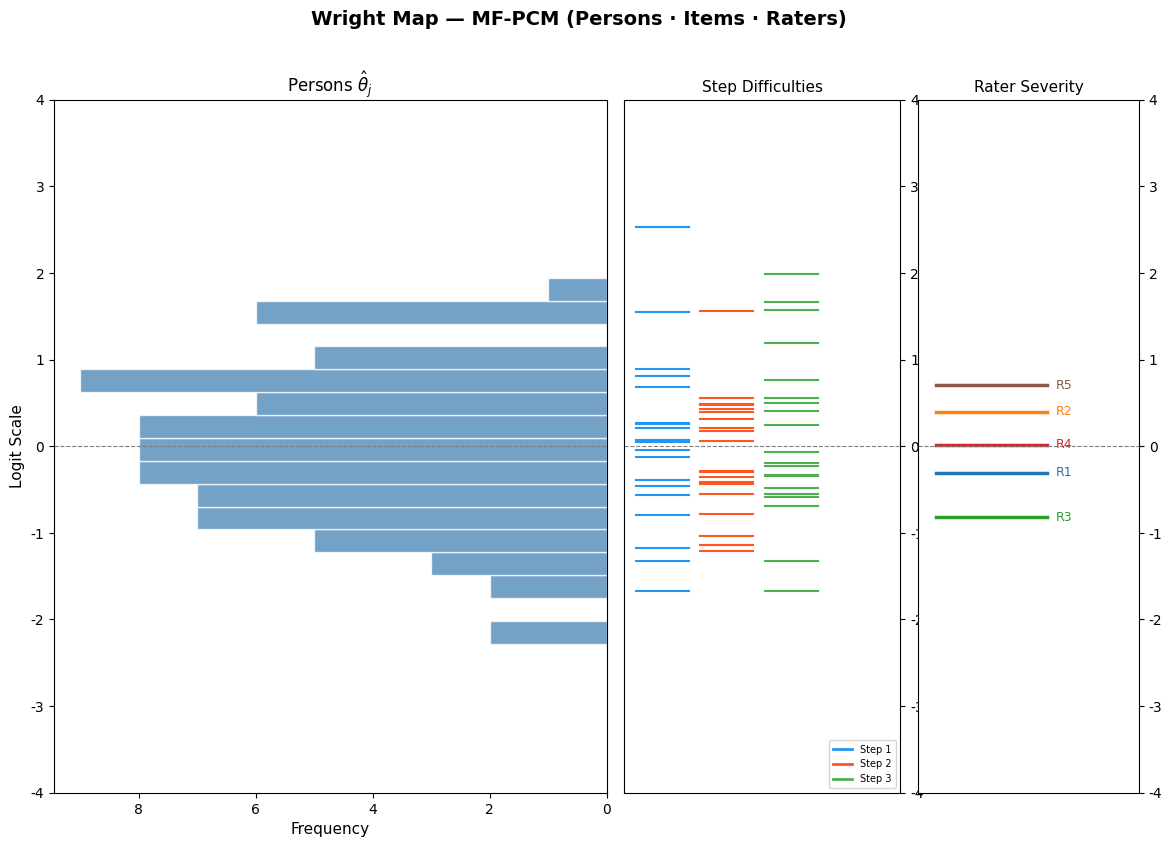

In [6]:
rater_colors = plt.cm.tab10(np.linspace(0, 0.5, R))
step_colors  = ['#2196F3', '#FF5722', '#4CAF50']

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(1, 3, width_ratios=[3, 1.5, 1.2], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
ax_r = fig.add_subplot(gs[2])
y_lim = (-4, 4)

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Persons $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        dv = delta_est[i, k]
        ax_i.plot([0.05 + k * 0.28, 0.28 + k * 0.28], [dv, dv],
                  color=step_colors[k], linewidth=1.5)
ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.2); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Step Difficulties', fontsize=11)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K-1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'Step {k+1}')
ax_i.legend(loc='lower right', fontsize=7)

for r, rv in enumerate(phi_est):
    ax_r.plot([0.1, 0.7], [rv, rv], color=rater_colors[r], linewidth=2.5)
    ax_r.text(0.75, rv, f'R{r+1}', fontsize=9, va='center', color=rater_colors[r])
ax_r.set_ylim(y_lim); ax_r.set_xlim(0, 1.2); ax_r.set_xticks([])
ax_r.set_yticks(range(-4, 5)); ax_r.yaxis.set_label_position('right'); ax_r.yaxis.tick_right()
ax_r.set_title('Rater Severity', fontsize=11)
ax_r.axhline(0, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle('Wright Map — MF-PCM (Persons · Items · Raters)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_mfpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC) — by Rater

**Interpretation**: The MF-PCM shifts each category boundary by rater severity. A harsh rater (large $\phi_r$) pushes the CRC peaks toward higher ability — meaning an equally able student receives lower expected scores from a harsher rater. The four curves (cat 0–3) within each rater should each show the expected bell-shape pattern, with category 0 dominant at low $\theta$ and category 3 dominant at high $\theta$.

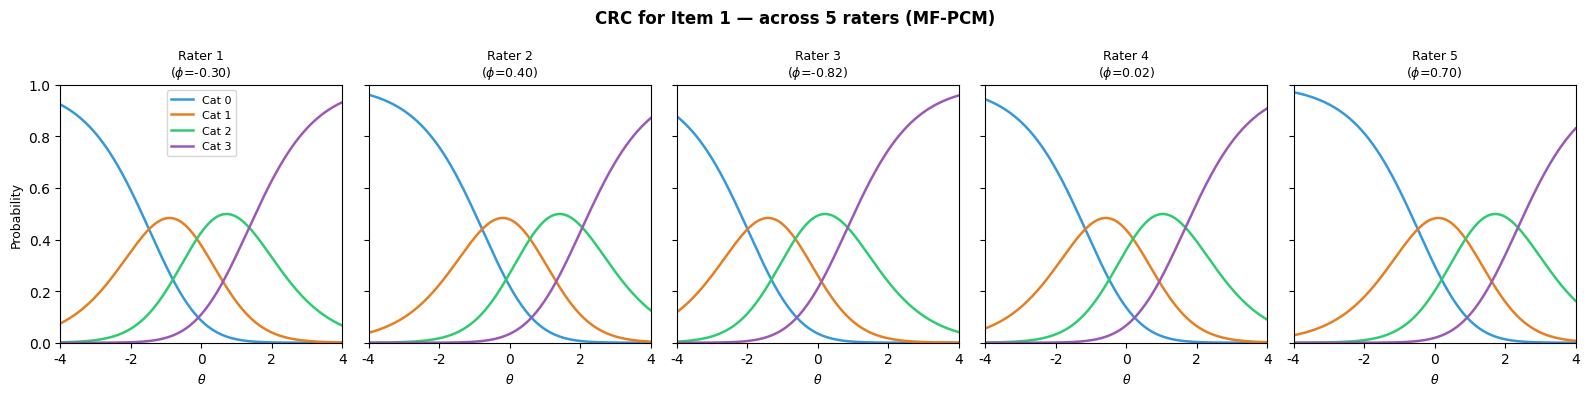

In [7]:
theta_range  = np.linspace(-4, 4, 300)
cat_colors   = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']
rater_ls     = ['-', '--', '-.', ':', (0, (3,1,1,1))]

# Show item 0 across all 5 raters
fig, axes = plt.subplots(1, R, figsize=(16, 4), sharey=True)
item_idx = 0
for r in range(R):
    ax = axes[r]
    for k in range(K):
        probs = [pcm_probs(t, delta_est[item_idx], phi_est[r])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=f'Cat {k}')
    ax.set_title(f'Rater {r+1}\n($\\phi$={phi_est[r]:.2f})', fontsize=9)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    ax.set_xlabel('$\\theta$', fontsize=9)
    if r == 0: ax.set_ylabel('Probability', fontsize=9)
    if r == 0: ax.legend(fontsize=8)

fig.suptitle(f'CRC for Item 1 — across 5 raters (MF-PCM)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_mfpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}_r(\theta) = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta, \hat{\delta}_i, \hat{\phi}_r)$$

**Interpretation**: Each rater's TCC is vertically offset relative to others. Students scored by the harshest rater receive a systematically lower expected total score at every ability level. The shaded gap between the most and least severe raters quantifies the expected score loss due to rater harshness — a direct measure of rater-induced unfairness in the scoring.

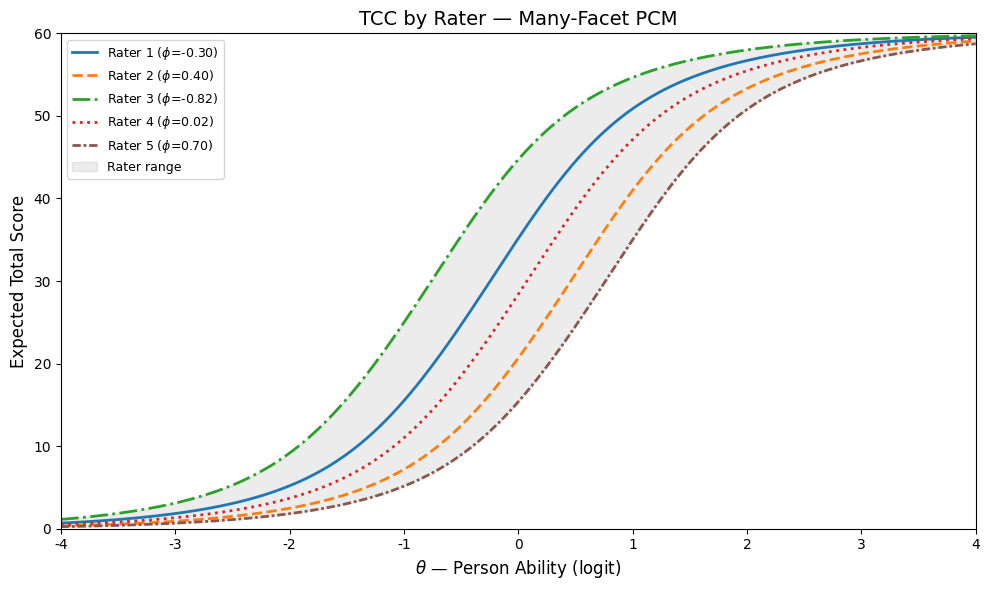

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
tcc_all = []
for r in range(R):
    tcc_r = np.zeros(len(theta_range))
    for i in range(I):
        for t_idx, t in enumerate(theta_range):
            pr = pcm_probs(t, delta_est[i], phi_est[r])
            tcc_r[t_idx] += np.dot(np.arange(K), pr)
    tcc_all.append(tcc_r)
    ax.plot(theta_range, tcc_r, color=rater_colors[r], linestyle=rater_ls[r],
            linewidth=2, label=f'Rater {r+1} ($\\phi$={phi_est[r]:.2f})')

tcc_arr = np.array(tcc_all)
ax.fill_between(theta_range, tcc_arr.min(axis=0), tcc_arr.max(axis=0),
                alpha=0.15, color='gray', label='Rater range')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('TCC by Rater — Many-Facet PCM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, I * (K - 1))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_mfpcm.png'), dpi=120, bbox_inches='tight')
plt.show()

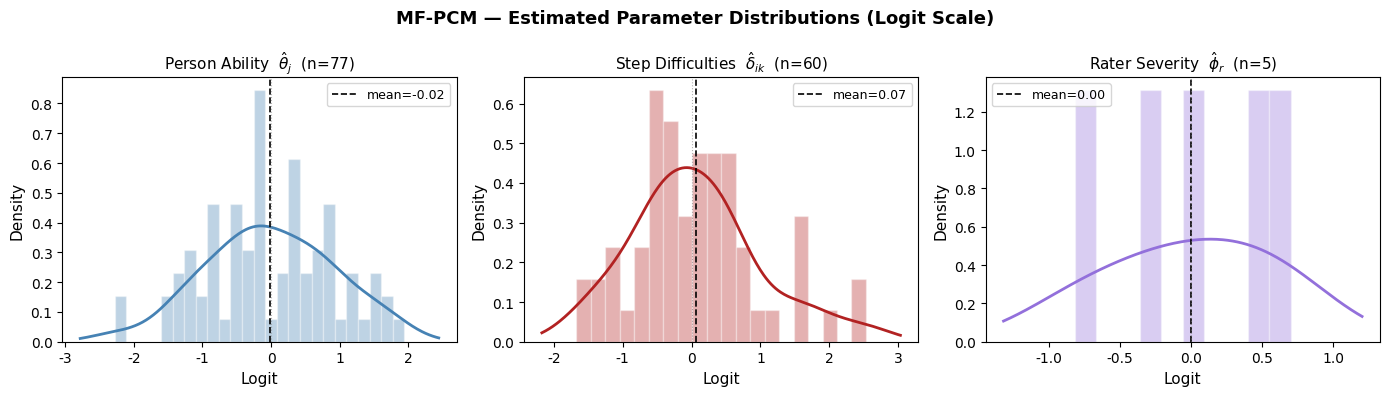

theta          : mean=-0.020  SD=0.922  range=[-2.28, 1.94]
delta (flat)   : mean=0.065  SD=0.928  range=[-1.67, 2.53]
phi            : mean=0.000  SD=0.533  range=[-0.82, 0.70]


In [9]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('MF-PCM — Estimated Parameter Distributions (Logit Scale)', fontsize=13, fontweight='bold')

delta_flat = delta_est.ravel()

panels = [
    (axes[0], theta_est,  r'Person Ability  $\hat{\theta}_j$',    'steelblue'),
    (axes[1], delta_flat, r'Step Difficulties  $\hat{\delta}_{ik}$', 'firebrick'),
    (axes[2], phi_est,    r'Rater Severity  $\hat{\phi}_r$',       'mediumpurple'),
]

for ax, vals, title, color in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Logit', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_mfpcm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('delta (flat)', delta_flat), ('phi', phi_est)]:
    print(f"{name:15s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
